# Hand-eye view YOLO26 Segmentation Fine-tuning Pipeline

흐름: 환경 설정 → 설정값 통합 → Drive 데이터셋 로컬 복사 → COCO→YOLO-seg 변환 → 라벨 검증 → 학습 → 검증 → 예측 → 모델 저장 → 마스크/중심점 추출.


## 1. Environment setup


In [2]:
!nvidia-smi

# Colab 기본 pandas 버전과 충돌하지 않도록 pandas는 2.2.2로 고정
!pip install -q -U ultralytics opencv-python-headless pycocotools pyyaml matplotlib
!pip install -q "pandas==2.2.2"

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import json
import glob
import shutil
import yaml
import random

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image as PILImage
from pycocotools import mask as mask_utils
from ultralytics import YOLO
from IPython.display import Image, display

print("pandas version:", pd.__version__)
print("torch cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Thu May 14 10:56:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             50W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Global configuration

여기만 수정하면 전체 코드의 경로와 모델 크기를 수정 가능


In [4]:
# =========================
# User config
# =========================
DRIVE_DATASET = Path('/content/drive/MyDrive/hand_eye_view_train_1280')

IMG_SIZE = 1280
MODEL_SIZE = 'm'       # n, s, m, l, x 중 선택. large 학습이면 'l', medium이면 'm'
MODEL_WEIGHTS = f'yolo26{MODEL_SIZE}-seg.pt'

EXPERIMENT_NAME = f'hand_eye_view_yolo26{MODEL_SIZE}_seg_{IMG_SIZE}_a100'

# =========================
# Local paths
# =========================
LOCAL_COCO_DIR = Path(f'/content/coco_dataset_{IMG_SIZE}')
YOLO_DATASET_DIR = Path(f'/content/hand_eye_view_yolo26_seg_{IMG_SIZE}')
DATA_YAML = YOLO_DATASET_DIR / 'data.yaml'

RUN_PROJECT = Path('/content/runs/segment')
RUN_NAME = EXPERIMENT_NAME
RUN_DIR = RUN_PROJECT / RUN_NAME
BEST_MODEL = RUN_DIR / 'weights' / 'best.pt'
LAST_MODEL = RUN_DIR / 'weights' / 'last.pt'

DRIVE_SAVE_DIR = Path('/content/drive/MyDrive/hand_eye_view_yolo_seg_result')
DRIVE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print('DRIVE_DATASET:', DRIVE_DATASET)
print('LOCAL_COCO_DIR:', LOCAL_COCO_DIR)
print('YOLO_DATASET_DIR:', YOLO_DATASET_DIR)
print('DATA_YAML:', DATA_YAML)
print('MODEL_WEIGHTS:', MODEL_WEIGHTS)
print('RUN_DIR:', RUN_DIR)
print('BEST_MODEL:', BEST_MODEL)
print('DEVICE:', DEVICE)

assert DRIVE_DATASET.exists(), f'Drive dataset not found: {DRIVE_DATASET}'


DRIVE_DATASET: /content/drive/MyDrive/hand_eye_view_train_1280
LOCAL_COCO_DIR: /content/coco_dataset_1280
YOLO_DATASET_DIR: /content/hand_eye_view_yolo26_seg_1280
DATA_YAML: /content/hand_eye_view_yolo26_seg_1280/data.yaml
MODEL_WEIGHTS: yolo26m-seg.pt
RUN_DIR: /content/runs/segment/hand_eye_view_yolo26m_seg_1280_a100
BEST_MODEL: /content/runs/segment/hand_eye_view_yolo26m_seg_1280_a100/weights/best.pt
DEVICE: 0


## 3. Copy dataset from Drive to Colab local


In [5]:
RESET_LOCAL_COPY = True

if RESET_LOCAL_COPY and LOCAL_COCO_DIR.exists():
    shutil.rmtree(LOCAL_COCO_DIR)

if not LOCAL_COCO_DIR.exists():
    shutil.copytree(DRIVE_DATASET, LOCAL_COCO_DIR)

print('Copied dataset to:', LOCAL_COCO_DIR)
print('\nTop-level files/folders:')
for p in sorted(LOCAL_COCO_DIR.iterdir()):
    print(' -', p)

json_files = sorted(LOCAL_COCO_DIR.rglob('*.json'))
print('\nJSON files:', len(json_files))
for j in json_files:
    print(' -', j)


Copied dataset to: /content/coco_dataset_1280

Top-level files/folders:
 - /content/coco_dataset_1280/README.dataset.txt
 - /content/coco_dataset_1280/README.roboflow.txt
 - /content/coco_dataset_1280/test
 - /content/coco_dataset_1280/train
 - /content/coco_dataset_1280/valid

JSON files: 3
 - /content/coco_dataset_1280/test/_annotations.coco.json
 - /content/coco_dataset_1280/train/_annotations.coco.json
 - /content/coco_dataset_1280/valid/_annotations.coco.json


## 4. Check COCO dataset structure


In [6]:
POSSIBLE_SPLITS = ['train', 'valid', 'val', 'test']

split_jsons = {}
for split in POSSIBLE_SPLITS:
    ann_path = LOCAL_COCO_DIR / split / '_annotations.coco.json'
    if ann_path.exists():
        split_jsons[split] = ann_path

print('Found splits:')
for split, path in split_jsons.items():
    print(f' - {split}: {path}')

assert 'train' in split_jsons, 'train/_annotations.coco.json을 찾지 못했습니다.'
assert ('valid' in split_jsons) or ('val' in split_jsons), 'valid 또는 val annotation을 찾지 못했습니다.'

with open(split_jsons['train'], 'r') as f:
    train_data = json.load(f)

categories = sorted(train_data['categories'], key=lambda c: c['id'])
names = [c['name'] for c in categories]
cat_id_to_idx = {c['id']: i for i, c in enumerate(categories)}

print('\nClasses:', names)
print('cat_id_to_idx:', cat_id_to_idx)


Found splits:
 - train: /content/coco_dataset_1280/train/_annotations.coco.json
 - valid: /content/coco_dataset_1280/valid/_annotations.coco.json
 - test: /content/coco_dataset_1280/test/_annotations.coco.json

Classes: ['hand-eye-view-train', 'cup']
cat_id_to_idx: {0: 0, 1: 1}


## 5. Convert COCO segmentation to YOLO segmentation


In [7]:
def find_image_path(split_dir: Path, file_name: str):
    """COCO json의 file_name과 실제 이미지 경로가 다를 수 있어서 보수적으로 찾습니다."""
    candidates = [
        split_dir / file_name,
        split_dir / Path(file_name).name,
    ]
    for p in candidates:
        if p.exists():
            return p

    matches = list(split_dir.rglob(Path(file_name).name))
    return matches[0] if matches else None


def polygon_area(poly):
    pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
    return abs(cv2.contourArea(pts))


def coco_seg_to_polygons(segmentation, width, height):
    """
    COCO segmentation을 polygon list로 변환합니다.
    - polygon format: [[x1,y1,x2,y2,...], ...]
    - RLE format: mask contour로 변환
    """
    polygons = []

    # COCO polygon format
    if isinstance(segmentation, list):
        for poly in segmentation:
            if isinstance(poly, list) and len(poly) >= 6:
                polygons.append(poly)
        return polygons

    # COCO RLE format
    if isinstance(segmentation, dict):
        rle = segmentation
        if isinstance(rle.get('counts'), list):
            rle = mask_utils.frPyObjects(rle, height, width)

        mask = mask_utils.decode(rle)
        if mask.ndim == 3:
            mask = np.any(mask, axis=2).astype(np.uint8)
        else:
            mask = mask.astype(np.uint8)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if len(cnt) >= 3:
                poly = cnt.reshape(-1, 2).astype(float).flatten().tolist()
                if len(poly) >= 6:
                    polygons.append(poly)
        return polygons

    return polygons


def normalize_polygon(poly, width, height):
    """YOLO segmentation format용 0~1 정규화 좌표로 변환합니다."""
    values = []
    for x, y in zip(poly[0::2], poly[1::2]):
        x = max(0.0, min(1.0, float(x) / float(width)))
        y = max(0.0, min(1.0, float(y) / float(height)))
        values.extend([x, y])
    return values


RESET_YOLO_DATASET = True
if RESET_YOLO_DATASET and YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)

YOLO_DATASET_DIR.mkdir(parents=True, exist_ok=True)

conversion_summary = {}

for split, ann_path in split_jsons.items():
    print(f'\nConverting split: {split}')

    split_dir = LOCAL_COCO_DIR / split
    out_img_dir = YOLO_DATASET_DIR / 'images' / split
    out_label_dir = YOLO_DATASET_DIR / 'labels' / split
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_label_dir.mkdir(parents=True, exist_ok=True)

    with open(ann_path, 'r') as f:
        data = json.load(f)

    images = {img['id']: img for img in data['images']}
    anns_by_image = {img_id: [] for img_id in images.keys()}
    for ann in data['annotations']:
        anns_by_image.setdefault(ann['image_id'], []).append(ann)

    converted_images = 0
    converted_objects = 0
    skipped_objects = 0
    missing_images = 0

    for img_id, img in images.items():
        file_name = Path(img['file_name']).name
        src_img_path = find_image_path(split_dir, img['file_name'])

        if src_img_path is None:
            print('Image not found, skip:', img['file_name'])
            missing_images += 1
            continue

        dst_img_path = out_img_dir / file_name
        shutil.copy2(src_img_path, dst_img_path)

        width = img.get('width')
        height = img.get('height')
        if width is None or height is None:
            with PILImage.open(src_img_path) as im:
                width, height = im.size

        label_lines = []

        for ann in anns_by_image.get(img_id, []):
            category_id = ann['category_id']
            if category_id not in cat_id_to_idx:
                skipped_objects += 1
                continue

            cls_idx = cat_id_to_idx[category_id]
            segmentation = ann.get('segmentation', [])
            polygons = coco_seg_to_polygons(segmentation, width, height)

            if len(polygons) == 0:
                skipped_objects += 1
                continue

            # 한 객체에 polygon이 여러 개 있으면 가장 큰 polygon만 사용
            polygons = sorted(polygons, key=polygon_area, reverse=True)
            poly = polygons[0]

            if len(poly) < 6:
                skipped_objects += 1
                continue

            norm_coords = normalize_polygon(poly, width, height)
            if len(norm_coords) < 6:
                skipped_objects += 1
                continue

            line = str(cls_idx) + ' ' + ' '.join(f'{v:.6f}' for v in norm_coords)
            label_lines.append(line)
            converted_objects += 1

        label_path = out_label_dir / (Path(file_name).stem + '.txt')
        label_path.write_text('\n'.join(label_lines))
        converted_images += 1

    conversion_summary[split] = {
        'converted_images': converted_images,
        'converted_objects': converted_objects,
        'skipped_objects': skipped_objects,
        'missing_images': missing_images,
    }

    print(conversion_summary[split])

val_split = 'valid' if 'valid' in split_jsons else 'val'
yaml_data = {
    'path': str(YOLO_DATASET_DIR),
    'train': 'images/train',
    'val': f'images/{val_split}',
    'names': names,
}
if 'test' in split_jsons:
    yaml_data['test'] = 'images/test'

with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(yaml_data, f, allow_unicode=True, sort_keys=False)

print('\nYOLO-seg dataset created at:', YOLO_DATASET_DIR)
print('\ndata.yaml:')
print(DATA_YAML.read_text())



Converting split: train
Image not found, skip: capture_20260504_153012_228_png.rf.ff7849136b94069d62b2b3d3c3032cac.jpg
{'converted_images': 138, 'converted_objects': 625, 'skipped_objects': 0, 'missing_images': 1}

Converting split: valid
{'converted_images': 40, 'converted_objects': 159, 'skipped_objects': 0, 'missing_images': 0}

Converting split: test
Image not found, skip: capture_20260504_152905_214_png.rf.0f6f3d87ae8fcfa7c7b17c66b5616af7.jpg
{'converted_images': 19, 'converted_objects': 72, 'skipped_objects': 0, 'missing_images': 1}

YOLO-seg dataset created at: /content/hand_eye_view_yolo26_seg_1280

data.yaml:
path: /content/hand_eye_view_yolo26_seg_1280
train: images/train
val: images/valid
names:
- hand-eye-view-train
- cup
test: images/test



## 6. Verify YOLO labels safely


In [8]:
def verify_yolo_seg_labels(yolo_dataset_dir: Path, split='train', show_n=3):
    label_files = sorted((yolo_dataset_dir / 'labels' / split).glob('*.txt'))
    non_empty = [p for p in label_files if p.read_text().strip()]

    print(f'[{split}] label file count:', len(label_files))
    print(f'[{split}] non-empty label count:', len(non_empty))

    if len(label_files) == 0:
        raise FileNotFoundError(f'No label txt files found: {yolo_dataset_dir / "labels" / split}')

    if len(non_empty) == 0:
        print('주의: 모든 label txt가 비어 있습니다. annotation 변환 또는 원본 COCO json을 확인하세요.')
        return None

    for sample_label in non_empty[:show_n]:
        lines = sample_label.read_text().strip().splitlines()
        print('\nSample label:', sample_label)
        print('first line:', lines[0])
        print('number of values:', len(lines[0].split()))
        if len(lines[0].split()) <= 5:
            print('주의: 값 개수가 5개 이하이면 segmentation polygon이 아니라 detection bbox 형식일 수 있습니다.')

    return non_empty

train_non_empty = verify_yolo_seg_labels(YOLO_DATASET_DIR, 'train')
val_non_empty = verify_yolo_seg_labels(YOLO_DATASET_DIR, val_split)


[train] label file count: 138
[train] non-empty label count: 138

Sample label: /content/hand_eye_view_yolo26_seg_1280/labels/train/capture_20260504_151617_026_png.rf.38fe62b464c1ec92d45001c7eed0370f.txt
first line: 1 0.529687 0.487500 0.528906 0.489063 0.526563 0.489063 0.525781 0.490625 0.523438 0.490625 0.522656 0.492188 0.521875 0.492188 0.521094 0.493750 0.518750 0.493750 0.517969 0.495312 0.516406 0.495312 0.515625 0.496875 0.514844 0.496875 0.514062 0.498437 0.513281 0.498437 0.512500 0.500000 0.510156 0.500000 0.503906 0.512500 0.503906 0.515625 0.500781 0.521875 0.500781 0.523438 0.500000 0.525000 0.499219 0.525000 0.499219 0.526563 0.498437 0.528125 0.498437 0.529687 0.497656 0.531250 0.497656 0.535937 0.496094 0.539062 0.496094 0.543750 0.495312 0.545312 0.495312 0.548438 0.494531 0.550000 0.494531 0.556250 0.493750 0.557813 0.493750 0.573438 0.494531 0.575000 0.494531 0.585938 0.495312 0.587500 0.495312 0.589063 0.496094 0.590625 0.496094 0.595313 0.496875 0.596875 0.496875

## 7. Train YOLO26 segmentation model


In [9]:
model = YOLO(MODEL_WEIGHTS)

results = model.train(
    data=str(DATA_YAML),
    task='segment',

    epochs=150,
    imgsz=IMG_SIZE,
    batch=0.70,          # A100 기준 자동 batch. OOM이면 8, 6, 4 등 정수로 낮추세요.
    patience=60,

    optimizer='auto',
    cos_lr=True,
    warmup_epochs=5.0,
    weight_decay=0.0005,

    overlap_mask=True,
    mask_ratio=2,

    hsv_h=0.015,
    hsv_s=0.45,
    hsv_v=0.30,
    degrees=5.0,
    translate=0.05,
    scale=0.30,
    shear=0.0,
    perspective=0.0003,
    flipud=0.0,
    fliplr=0.5,

    mosaic=0.30,
    close_mosaic=20,
    mixup=0.0,
    copy_paste=0.0,

    device=DEVICE,
    workers=8,
    amp=True,
    cache='ram',
    plots=True,
    save=True,
    save_period=10,

    project=str(RUN_PROJECT),
    name=RUN_NAME,
    exist_ok=True,
)

print('RUN_DIR:', RUN_DIR)
print('BEST_MODEL exists:', BEST_MODEL.exists(), BEST_MODEL)
print('LAST_MODEL exists:', LAST_MODEL.exists(), LAST_MODEL)


Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=0.7, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/hand_eye_view_yolo26_seg_1280/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.45, hsv_v=0.3, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=2, max_det=300, mixup=0.0, mode=train, model=yolo26m-seg.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=hand_eye_view_yolo26m_seg_1280_a100, nbs=64, nms=False, opset=None, o

## 8. Validate best.pt


In [10]:
assert BEST_MODEL.exists(), f'best.pt not found: {BEST_MODEL}'

model = YOLO(str(BEST_MODEL))
metrics = model.val(
    data=str(DATA_YAML),
    task='segment',
    imgsz=IMG_SIZE,
    batch=8,
    device=DEVICE,
    plots=True,
)

print('box mAP50-95:', metrics.box.map)
print('box mAP50:', metrics.box.map50)
print('mask mAP50-95:', metrics.seg.map)
print('mask mAP50:', metrics.seg.map50)


Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26m-seg summary (fused): 149 layers, 23,509,010 parameters, 0 gradients, 121.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1640.1±624.9 MB/s, size: 48.4 KB)
val: Scanning /content/hand_eye_view_yolo26_seg_1280/labels/valid.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 18.6Mit/s 0.0s
val: /content/hand_eye_view_yolo26_seg_1280/images/valid/capture_20260504_152524_186_png.rf.c919117f65a971eca920253c13f99995.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.6it/s 1.4s
                   all         40        158      0.958      0.875      0.952      0.899      0.988      0.854      0.889      0.845
                   cup         40        158      0.958      0.875      0.952      0.899      0.988      0.854      0.88

## 9. Predict sample images


source_dir: /content/hand_eye_view_yolo26_seg_1280/images/test
image count: 19
sample image: /content/hand_eye_view_yolo26_seg_1280/images/test/capture_20260504_151642_033_png.rf.15b9296d1d2873c2bf245e428c869215.jpg

image 1/1 /content/hand_eye_view_yolo26_seg_1280/images/test/capture_20260504_151642_033_png.rf.15b9296d1d2873c2bf245e428c869215.jpg: 640x1280 1 cup, 99.8ms
Speed: 2.8ms preprocess, 99.8ms inference, 7.5ms postprocess per image at shape (1, 3, 640, 1280)
Results saved to /content/preds/hand_eye_view_yolo26m_seg_1280_a100_single
저장 위치: /content/preds/hand_eye_view_yolo26m_seg_1280_a100_single


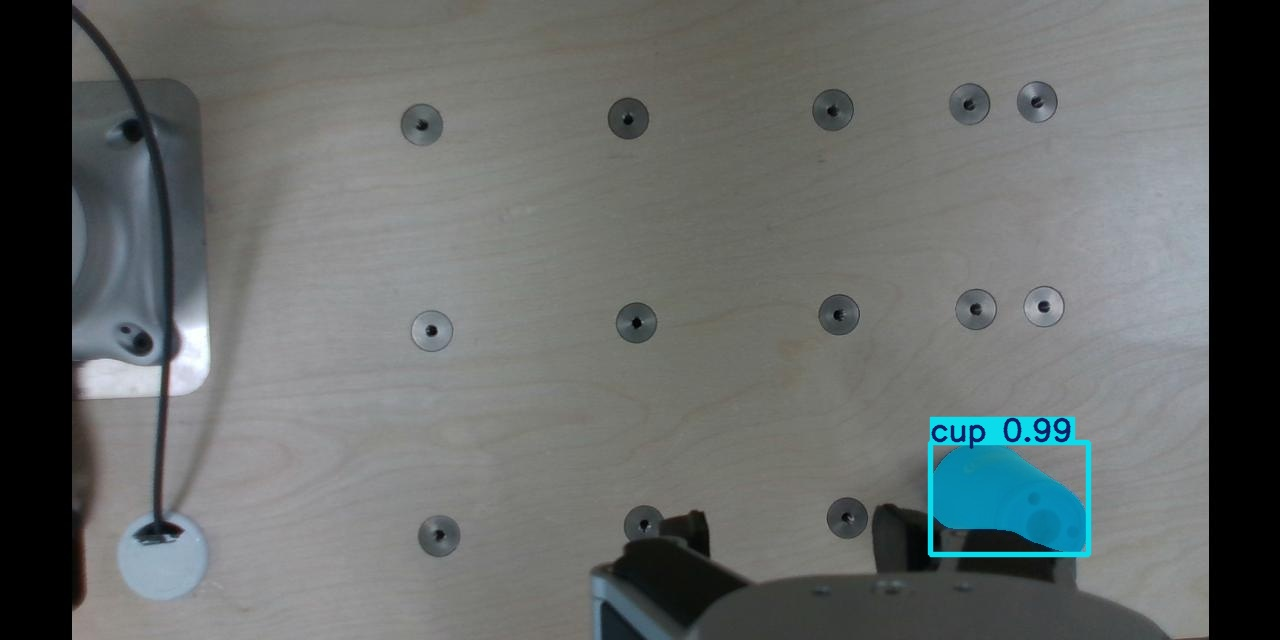

In [11]:
model = YOLO(str(BEST_MODEL))

candidate_dirs = []
if (YOLO_DATASET_DIR / 'images' / 'test').exists():
    candidate_dirs.append(YOLO_DATASET_DIR / 'images' / 'test')
candidate_dirs.append(YOLO_DATASET_DIR / 'images' / val_split)
candidate_dirs.append(YOLO_DATASET_DIR / 'images' / 'train')

source_dir = next((d for d in candidate_dirs if d.exists() and len(list(d.glob('*'))) > 0), None)
assert source_dir is not None, 'No image directory found for prediction.'

image_files = sorted([p for p in source_dir.glob('*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
print('source_dir:', source_dir)
print('image count:', len(image_files))

source_img = image_files[0]
print('sample image:', source_img)

pred_results = model.predict(
    source=str(source_img),
    task='segment',
    imgsz=IMG_SIZE,
    conf=0.25,
    iou=0.7,
    device=DEVICE,
    save=True,
    retina_masks=True,
    project='/content/preds',
    name=f'{EXPERIMENT_NAME}_single',
    exist_ok=True,
)

print('저장 위치:', pred_results[0].save_dir)
pred_dir = Path(pred_results[0].save_dir)
for p in sorted(pred_dir.glob('*'))[:5]:
    display(Image(filename=str(p)))


## 10. Save trained model and run folder to Google Drive


In [12]:
assert BEST_MODEL.exists(), f'best.pt not found: {BEST_MODEL}'

best_dst = DRIVE_SAVE_DIR / f'{EXPERIMENT_NAME}_best.pt'
last_dst = DRIVE_SAVE_DIR / f'{EXPERIMENT_NAME}_last.pt'
shutil.copy2(BEST_MODEL, best_dst)
print('Saved best.pt to:', best_dst)

if LAST_MODEL.exists():
    shutil.copy2(LAST_MODEL, last_dst)
    print('Saved last.pt to:', last_dst)

# 전체 runs 폴더도 zip으로 저장하고 싶을 때
zip_base = DRIVE_SAVE_DIR / EXPERIMENT_NAME
zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir=str(RUN_DIR))
print('Saved run zip to:', zip_path)


Saved best.pt to: /content/drive/MyDrive/hand_eye_view_yolo_seg_result/hand_eye_view_yolo26m_seg_1280_a100_best.pt
Saved last.pt to: /content/drive/MyDrive/hand_eye_view_yolo_seg_result/hand_eye_view_yolo26m_seg_1280_a100_last.pt
Saved run zip to: /content/drive/MyDrive/hand_eye_view_yolo_seg_result/hand_eye_view_yolo26m_seg_1280_a100.zip


## 11. Single-image mask, bbox, confidence, center extraction



image 1/1 /content/hand_eye_view_yolo26_seg_1280/images/test/capture_20260504_151642_033_png.rf.15b9296d1d2873c2bf245e428c869215.jpg: 640x1280 1 cup, 16.8ms
Speed: 2.9ms preprocess, 16.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 1280)
Results saved to /content/preds/hand_eye_view_yolo26m_seg_1280_a100_analysis


,id,class_id,class_name,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2,center_x,center_y,mask_area_px,mask_path
0,0,1,cup,0.9906,930,442,1088,554,1006,497,11438,/content/hand_eye_view_yolo26m_seg_1280_a100_m...


mask 저장 폴더: /content/hand_eye_view_yolo26m_seg_1280_a100_masks
csv 저장: /content/hand_eye_view_yolo26m_seg_1280_a100_masks/segmentation_objects.csv


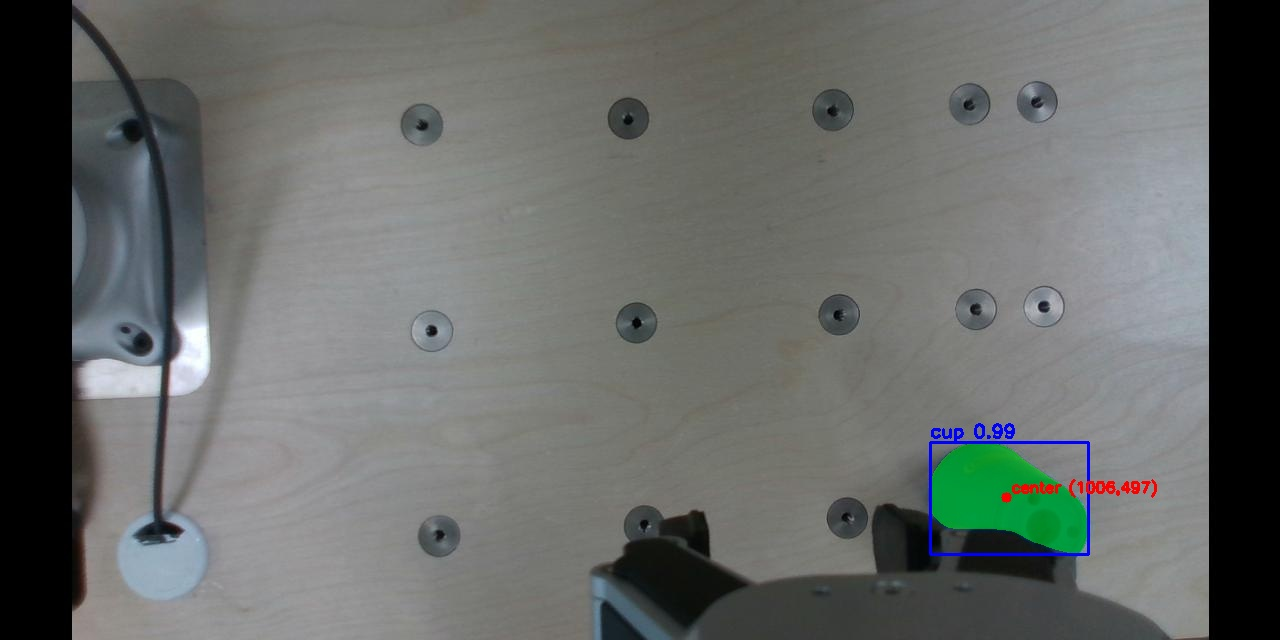

overlay saved: /content/hand_eye_view_yolo26m_seg_1280_a100_overlay.jpg


In [13]:
# 원하는 이미지로 바꿔서 사용하세요.
INPUT_IMAGE = str(source_img)
SAVE_MASK_DIR = Path(f'/content/{EXPERIMENT_NAME}_masks')
SAVE_MASK_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO(str(BEST_MODEL))
results = model.predict(
    source=INPUT_IMAGE,
    task='segment',
    imgsz=IMG_SIZE,
    conf=0.25,
    iou=0.7,
    device=DEVICE,
    save=True,
    retina_masks=True,
    project='/content/preds',
    name=f'{EXPERIMENT_NAME}_analysis',
    exist_ok=True,
)

result = results[0]
img = cv2.imread(INPUT_IMAGE)
assert img is not None, f'이미지를 읽지 못했습니다: {INPUT_IMAGE}'
H, W = img.shape[:2]

info_list = []
overlay = img.copy()

if result.masks is None:
    print('검출된 segmentation mask가 없습니다.')
else:
    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    for i, mask in enumerate(masks):
        mask_bin = (mask > 0.5).astype(np.uint8)
        if mask_bin.shape != (H, W):
            mask_bin = cv2.resize(mask_bin, (W, H), interpolation=cv2.INTER_NEAREST)

        area = int(mask_bin.sum())
        M = cv2.moments(mask_bin)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
        else:
            cx, cy = -1, -1

        x1, y1, x2, y2 = boxes[i].astype(int)
        cls_id = int(classes[i])
        cls_name = model.names[cls_id]
        conf = float(confs[i])

        mask_img = (mask_bin * 255).astype(np.uint8)
        mask_path = SAVE_MASK_DIR / f'object_{i:02d}_mask.png'
        cv2.imwrite(str(mask_path), mask_img)

        color = np.array([0, 255, 0], dtype=np.uint8)
        overlay[mask_bin == 1] = overlay[mask_bin == 1] * 0.5 + color * 0.5
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 0, 0), 2)
        if cx >= 0 and cy >= 0:
            cv2.circle(overlay, (cx, cy), 5, (0, 0, 255), -1)
            cv2.putText(overlay, f'center ({cx},{cy})', (cx + 5, cy - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        cv2.putText(overlay, f'{cls_name} {conf:.2f}', (x1, max(y1 - 5, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        info_list.append({
            'id': i,
            'class_id': cls_id,
            'class_name': cls_name,
            'confidence': round(conf, 4),
            'bbox_x1': x1,
            'bbox_y1': y1,
            'bbox_x2': x2,
            'bbox_y2': y2,
            'center_x': cx,
            'center_y': cy,
            'mask_area_px': area,
            'mask_path': str(mask_path),
        })

    df = pd.DataFrame(info_list)
    display(df)
    csv_path = SAVE_MASK_DIR / 'segmentation_objects.csv'
    df.to_csv(csv_path, index=False)
    print('mask 저장 폴더:', SAVE_MASK_DIR)
    print('csv 저장:', csv_path)

out_path = f'/content/{EXPERIMENT_NAME}_overlay.jpg'
cv2.imwrite(out_path, overlay)
display(Image(filename=out_path))
print('overlay saved:', out_path)
